# Step 3 — Sentiment Scoring and Final Dataset Assembly


## 1. Imports


In [1]:
# %pip install transformers torch pandas numpy pyarrow matplotlib tqdm

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration


In [2]:
# CONFIGURATION

TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

MODEL_NAME = "ProsusAI/finbert"
BATCH_SIZE = 32
MAX_LENGTH = 64   # headlines are short; keeps inference fast

RAW_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else -1

print("Model:", MODEL_NAME)
print("Batch size:", BATCH_SIZE)
print("Device:", "GPU" if DEVICE == 0 else "CPU")
print("Raw data directory:", RAW_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Model: ProsusAI/finbert
Batch size: 32
Device: CPU
Raw data directory: D:\Projects\stock-market-prediction\data\raw
Output directory: D:\Projects\stock-market-prediction\data\processed


## 3. Load Step 1 and Step 2 Datasets


In [3]:
stock_data = pd.read_parquet(RAW_DIR / "combined_stock_data.parquet")
news_data = pd.read_parquet(RAW_DIR / "financial_news_raw.parquet")

stock_data["Date"] = pd.to_datetime(stock_data["Date"])
news_data["Date"] = pd.to_datetime(news_data["Date"])

print("Stock data shape:", stock_data.shape)
print("News data shape:", news_data.shape)


Stock data shape: (3016, 8)
News data shape: (28699, 3)


## 4. Inspect Loaded Data


In [4]:
print("=" * 70)
print("STOCK DATA")
print("=" * 70)
print(stock_data.dtypes)
display(stock_data.head(3))

print("\n" + "=" * 70)
print("NEWS DATA")
print("=" * 70)
print(news_data.dtypes)
display(news_data.head(3))


STOCK DATA
Date         datetime64[ms]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
dtype: object


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2021-02-01,AAPL,133.750000,135.380005,130.929993,134.139999,130.224442,106239800
1,2021-02-01,MSFT,235.059998,242.500000,232.429993,239.649994,228.934204,33314200
2,2021-02-01,NVDA,13.053250,13.270750,12.902750,13.237000,13.183801,217204000



NEWS DATA
Date      datetime64[us]
Ticker               str
Text                 str
dtype: object


,Date,Ticker,Text
0,2021-02-01,AAPL,this unusual options alert can help traders di...
1,2021-02-01,AAPL,shares of apple (nasdaq: aapl ) saw some unusu...
2,2021-02-01,AAPL,"each day, benzinga takes a look back at a nota..."


## 5. Load FinBERT


In [5]:
# LOAD MODEL AND TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if DEVICE == 0 else "cpu")
model.to(device)
model.eval()

# FinBERT label order per config.id2label
id2label = model.config.id2label
print("Label mapping:", id2label)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14355.25it/s]

Label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


## 6. Score All Headlines


In [6]:
# BATCH SENTIMENT SCORING

texts = news_data["Text"].tolist()

all_probs = []

with torch.no_grad():
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="Scoring headlines"):
        batch = texts[start:start + BATCH_SIZE]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(device)

        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

all_probs = np.concatenate(all_probs, axis=0)

label_names = [id2label[i] for i in range(len(id2label))]
prob_df = pd.DataFrame(all_probs, columns=[f"P_{name.capitalize()}" for name in label_names])

news_data = pd.concat([news_data.reset_index(drop=True), prob_df], axis=1)

news_data["Sentiment_Label"] = news_data[[f"P_{name.capitalize()}" for name in label_names]].idxmax(axis=1).str.replace("P_", "", regex=False)
news_data["Sentiment_Score"] = news_data["P_Positive"] - news_data["P_Negative"]

print("Scoring complete.")
print("Shape:", news_data.shape)


Scoring headlines: 100%|██████████| 897/897 [30:13<00:00,  2.02s/it]

Scoring complete.
Shape: (28699, 8)


## 7. Inspect Sentiment Scores


In [7]:
print("Label distribution:")
print(news_data["Sentiment_Label"].value_counts())

print("\nSentiment_Score summary:")
print(news_data["Sentiment_Score"].describe())

print("\nExample scored headlines:")
display(
    news_data[["Date", "Ticker", "Text", "Sentiment_Label", "Sentiment_Score"]]
    .sample(5, random_state=42)
)


Label distribution:
Sentiment_Label
Neutral     13492
Negative     8573
Positive     6634
Name: count, dtype: int64

Sentiment_Score summary:
count    28699.000000
mean        -0.066761
std          0.607765
min         -0.969916
25%         -0.618084
50%         -0.002400
75%          0.321506
max          0.942696
Name: Sentiment_Score, dtype: float64

Example scored headlines:


,Date,Ticker,Text,Sentiment_Label,Sentiment_Score
8318,2023-03-21,AAPL,alphabet inc’s (nasdaq: goog ) (nasdaq: googl ...,Neutral,0.204452
17979,2023-08-28,NVDA,"u.s. stocks closed higher on friday, with the ...",Negative,-0.863360
22914,2021-12-28,TSLA,tokenized shares of tesla inc (nasdaq: tsla ) ...,Neutral,0.006278
10274,2023-11-16,MSFT,goldman sachs projected a bullish scenario for...,Positive,0.923578
18790,2021-09-16,TSLA,"on wednesday, the time 100 most influential pe...",Neutral,-0.001018


## 8. Aggregate Daily Sentiment Features per Ticker


In [8]:
# DAILY SENTIMENT AGGREGATION

sentiment_daily = (
    news_data
    .groupby(["Date", "Ticker"])
    .agg(
        Sentiment_Mean=("Sentiment_Score", "mean"),
        Sentiment_Std=("Sentiment_Score", "std"),
        Headline_Count=("Sentiment_Score", "count")
    )
    .reset_index()
)

sentiment_daily["Sentiment_Std"] = sentiment_daily["Sentiment_Std"].fillna(0.0)

print("Daily sentiment feature shape:", sentiment_daily.shape)
display(sentiment_daily.head(10))


Daily sentiment feature shape: (3963, 5)


,Date,Ticker,Sentiment_Mean,Sentiment_Std,Headline_Count
0,2021-02-01,AAPL,-0.153800,0.235510,5
1,2021-02-01,MSFT,0.161883,0.793238,2
2,2021-02-01,NVDA,-0.657178,0.365090,2
3,2021-02-01,TSLA,0.237143,0.620807,11
4,2021-02-02,AAPL,0.022793,0.554306,4
5,2021-02-02,MSFT,-0.968383,0.000000,1
6,2021-02-02,NVDA,-0.940379,0.000000,1
7,2021-02-02,TSLA,-0.290197,0.465469,10
8,2021-02-03,AAPL,-0.256913,0.435094,5
9,2021-02-03,MSFT,0.049416,0.631880,9


## 9. Merge Sentiment Features with Stock Data


In [9]:
# MERGE INTO FINAL COMBINED DATASET

final_data = stock_data.merge(
    sentiment_daily,
    on=["Date", "Ticker"],
    how="left"
)

final_data["Has_News"] = final_data["Headline_Count"].notna()

fill_cols = ["Sentiment_Mean", "Sentiment_Std", "Headline_Count"]
final_data[fill_cols] = final_data[fill_cols].fillna(0.0)
final_data["Headline_Count"] = final_data["Headline_Count"].astype(int)

print("Final combined dataset shape:", final_data.shape)
display(final_data.head(10))


Final combined dataset shape: (3016, 12)


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,Sentiment_Mean,Sentiment_Std,Headline_Count,Has_News
0,2021-02-01,AAPL,133.750000,135.380005,130.929993,134.139999,130.224442,106239800,-0.153800,0.235510,5,True
1,2021-02-01,MSFT,235.059998,242.500000,232.429993,239.649994,228.934204,33314200,0.161883,0.793238,2,True
2,2021-02-01,NVDA,13.053250,13.270750,12.902750,13.237000,13.183801,217204000,-0.657178,0.365090,2,True
3,2021-02-01,TSLA,271.429993,280.666656,265.186676,279.936676,279.936676,76174200,0.237143,0.620807,11,True
4,2021-02-02,AAPL,135.729996,136.309998,134.610001,134.990005,131.049622,83305400,0.022793,0.554306,4,True
5,2021-02-02,MSFT,241.300003,242.309998,238.690002,239.509995,228.800430,25916300,-0.968383,0.000000,1,True
6,2021-02-02,NVDA,13.398750,13.572000,13.285500,13.556750,13.502266,220440000,-0.940379,0.000000,1,True
7,2021-02-02,TSLA,281.559998,293.500000,280.733337,290.929993,290.929993,73038600,-0.290197,0.465469,10,True
8,2021-02-03,AAPL,135.759995,135.770004,133.610001,133.940002,130.030258,89880900,-0.256913,0.435094,5,True
9,2021-02-03,MSFT,239.570007,245.089996,239.259995,243.000000,232.134415,27158100,0.049416,0.631880,9,True


## 10. Validate the Final Combined Dataset


In [10]:
print("Columns:", final_data.columns.tolist())

print("\nMissing values:")
print(final_data.isna().sum())

print("\nDuplicate Date + Ticker records:", final_data.duplicated(subset=["Date", "Ticker"]).sum())

print("\nNews coverage by ticker (share of trading days with at least one headline):")
print(final_data.groupby("Ticker")["Has_News"].mean().round(3))

print("\nSentiment_Mean summary by ticker:")
print(final_data.groupby("Ticker")["Sentiment_Mean"].describe())


Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Sentiment_Mean', 'Sentiment_Std', 'Headline_Count', 'Has_News']

Missing values:
Date              0
Ticker            0
Open              0
High              0
Low               0
Close             0
Adj_Close         0
Volume            0
Sentiment_Mean    0
Sentiment_Std     0
Headline_Count    0
Has_News          0
dtype: int64

Duplicate Date + Ticker records: 0

News coverage by ticker (share of trading days with at least one headline):
Ticker
AAPL    1.000
MSFT    0.988
NVDA    0.940
TSLA    1.000
Name: Has_News, dtype: float64

Sentiment_Mean summary by ticker:
        count      mean       std       min       25%       50%       75%  \
Ticker                                                                      
AAPL    754.0 -0.085145  0.212469 -0.774438 -0.214251 -0.085323  0.042593   
MSFT    754.0 -0.059141  0.290496 -0.968383 -0.242582 -0.040596  0.125579   
NVDA    754.0 -0.059840  0.36091

## 11. Optional: Manual Spot-Check for an Ad Hoc Accuracy Estimate


In [11]:
SPOT_CHECK_SAMPLE_SIZE = 150

spot_check = news_data[["Date", "Ticker", "Text", "Sentiment_Label"]].sample(
    SPOT_CHECK_SAMPLE_SIZE, random_state=42
).reset_index(drop=True)

spot_check["Manual_Label"] = ""   # fill in by hand: positive / negative / neutral

spot_check_path = OUTPUT_DIR / "sentiment_manual_spot_check.csv"
spot_check.to_csv(spot_check_path, index=False)

print(f"Saved {SPOT_CHECK_SAMPLE_SIZE} headlines for manual review to:")
print(spot_check_path.resolve())
print("\nAfter filling in Manual_Label by hand, reload the file and compare it against Sentiment_Label")
print("to compute a dataset-specific accuracy estimate.")


Saved 150 headlines for manual review to:
D:\Projects\stock-market-prediction\data\processed\sentiment_manual_spot_check.csv

After filling in Manual_Label by hand, reload the file and compare it against Sentiment_Label
to compute a dataset-specific accuracy estimate.


## 12. Exploratory Visualization — Price vs. Sentiment


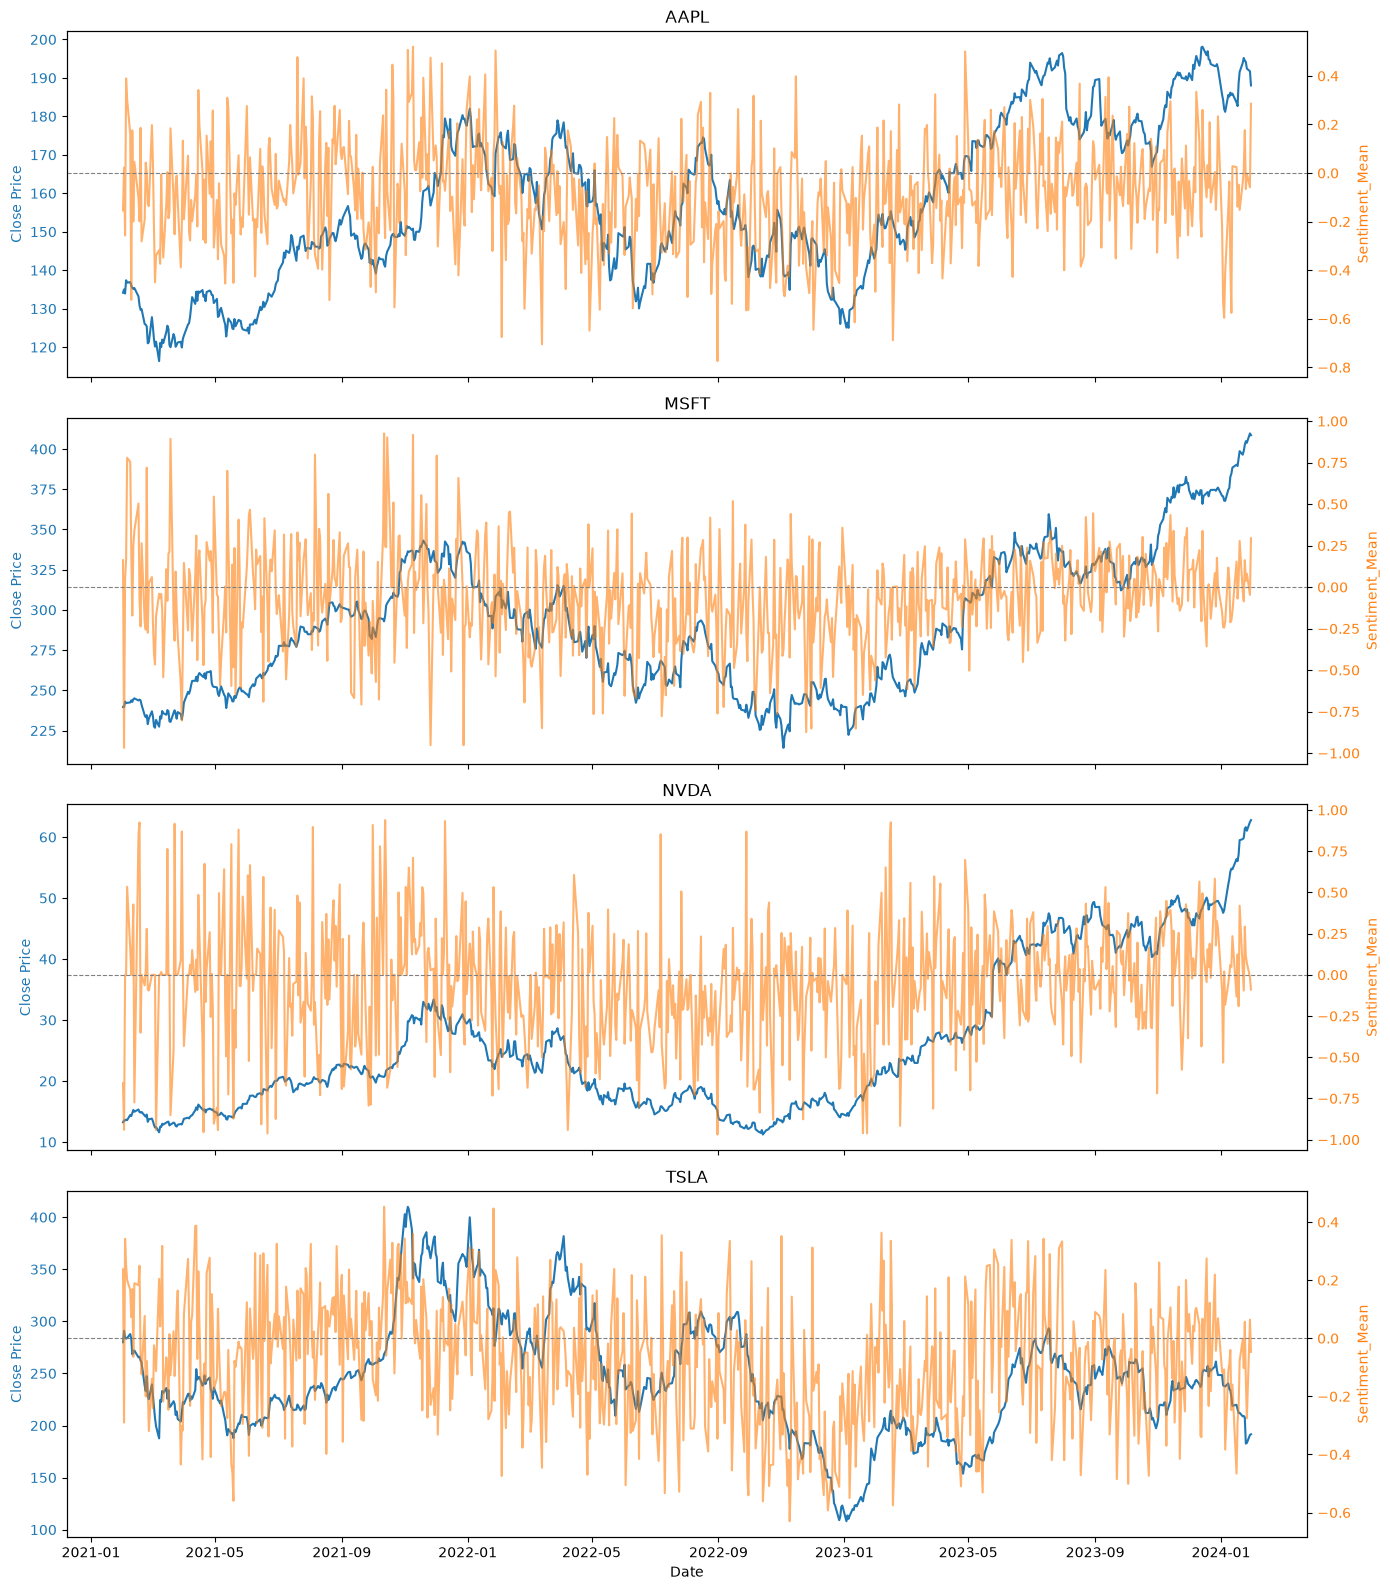

In [12]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 4 * len(TICKERS)), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    ticker_data = final_data[final_data["Ticker"] == ticker].sort_values("Date")

    ax.plot(ticker_data["Date"], ticker_data["Close"], color="tab:blue", label="Close Price")
    ax.set_ylabel("Close Price", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax.set_title(ticker)

    ax2 = ax.twinx()
    ax2.plot(ticker_data["Date"], ticker_data["Sentiment_Mean"], color="tab:orange", alpha=0.6, label="Sentiment_Mean")
    ax2.set_ylabel("Sentiment_Mean", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.axhline(0, color="grey", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 13. Save the Final Combined Dataset


In [13]:
# Full per-headline scored news (for provenance / appendix)
news_scored_csv = OUTPUT_DIR / "financial_news_scored.csv"
news_scored_parquet = OUTPUT_DIR / "financial_news_scored.parquet"
news_data.to_csv(news_scored_csv, index=False)
news_data.to_parquet(news_scored_parquet, index=False)

# Daily sentiment features alone
sentiment_daily_csv = OUTPUT_DIR / "sentiment_daily_features.csv"
sentiment_daily_parquet = OUTPUT_DIR / "sentiment_daily_features.parquet"
sentiment_daily.to_csv(sentiment_daily_csv, index=False)
sentiment_daily.to_parquet(sentiment_daily_parquet, index=False)

# Final combined modeling dataset
final_csv = OUTPUT_DIR / "final_combined_dataset.csv"
final_parquet = OUTPUT_DIR / "final_combined_dataset.parquet"
final_data.to_csv(final_csv, index=False)
final_data.to_parquet(final_parquet, index=False)

print("Saved:")
for p in [news_scored_csv, news_scored_parquet, sentiment_daily_csv, sentiment_daily_parquet, final_csv, final_parquet]:
    print(" -", p.resolve())


Saved:
 - D:\Projects\stock-market-prediction\data\processed\financial_news_scored.csv
 - D:\Projects\stock-market-prediction\data\processed\financial_news_scored.parquet
 - D:\Projects\stock-market-prediction\data\processed\sentiment_daily_features.csv
 - D:\Projects\stock-market-prediction\data\processed\sentiment_daily_features.parquet
 - D:\Projects\stock-market-prediction\data\processed\final_combined_dataset.csv
 - D:\Projects\stock-market-prediction\data\processed\final_combined_dataset.parquet


## 14. Final Validation


In [14]:
print("=" * 60)
print("STEP 3 VALIDATION")
print("=" * 60)

print("\nFinal dataset shape:", final_data.shape)
print("\nColumns:", final_data.columns.tolist())

print("\nRows per ticker:")
print(final_data["Ticker"].value_counts())

print("\nDate range:", final_data["Date"].min(), "to", final_data["Date"].max())

print("\nMissing values:")
print(final_data.isna().sum())

print("\nDuplicate Date + Ticker records:", final_data.duplicated(subset=["Date", "Ticker"]).sum())

print("\nOverall news coverage:", f"{final_data['Has_News'].mean():.1%} of trading days have at least one headline")

print("\nStep 3 complete: final combined dataset is ready for modeling (Chapter 3).")


STEP 3 VALIDATION

Final dataset shape: (3016, 12)

Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Sentiment_Mean', 'Sentiment_Std', 'Headline_Count', 'Has_News']

Rows per ticker:
Ticker
AAPL    754
MSFT    754
NVDA    754
TSLA    754
Name: count, dtype: int64

Date range: 2021-02-01 00:00:00 to 2024-01-30 00:00:00

Missing values:
Date              0
Ticker            0
Open              0
High              0
Low               0
Close             0
Adj_Close         0
Volume            0
Sentiment_Mean    0
Sentiment_Std     0
Headline_Count    0
Has_News          0
dtype: int64

Duplicate Date + Ticker records: 0

Overall news coverage: 98.2% of trading days have at least one headline

Step 3 complete: final combined dataset is ready for modeling (Chapter 3).


## Important Methodological Note
